PHASE3: TRANSFORM FX PRICES INTO FINANCIAL VARIABLES

Step4: Calculate Daily FX Returns

In [5]:
import pandas as pd

df_fx_curr = pd.read_csv("../data/processed/fx_dataset_clean.csv")
df_fx_curr["Day"] = pd.to_datetime(df_fx_curr["Day"])

# ============================================================
# STEP 4.1 — Prepare Return Dataset
# ============================================================

df_returns = df_fx_curr.copy()

# ============================================================
# STEP 4.2 — Calculate Daily FX Returns
# ============================================================

for currency in df_fx_curr.columns[1:]:
    return_name = currency.replace("Value-", "") + "_return"
    df_returns[return_name] = df_returns[currency].pct_change()    # R(t)=P(t)-P(t-1)/P(t-1)

print("Shape:", df_returns.shape)

print("\nColumns:")
print(df_returns.columns.tolist())

print("\nFirst 5 rows:")
print(df_returns.head())

# ============================================================
# STEP 4.3 — Check Daily Returns
# ============================================================

return_columns = [col for col in df_returns.columns if col.endswith("_return")]

print("Number of return columns:", len(return_columns))
print("\nReturn columns:")
print(return_columns)

print("\nMissing values in return columns:")
print(df_returns[return_columns].isna().sum())

print("\nSummary statistics of returns:")
print(df_returns[return_columns].describe())

Shape: (2996, 19)

Columns:
['Day', 'Value-CNY', 'Value-EUR', 'Value-INR', 'Value-ZAR', 'Value-TRY', 'Value-JPY', 'Value-GBP', 'Value-BRL', 'Value-AUD', 'CNY_return', 'EUR_return', 'INR_return', 'ZAR_return', 'TRY_return', 'JPY_return', 'GBP_return', 'BRL_return', 'AUD_return']

First 5 rows:
         Day  Value-CNY  Value-EUR  Value-INR  Value-ZAR  Value-TRY  \
0 2015-01-02   6.207673   0.830358  63.356307  11.661131   2.352570   
1 2015-01-05   6.219975   0.839278  63.462526  11.727990   2.338984   
2 2015-01-06   6.213027   0.839349  63.572268  11.731660   2.327682   
3 2015-01-07   6.213507   0.845237  63.174964  11.713972   2.328375   
4 2015-01-08   6.216179   0.849762  62.567981  11.634262   2.309738   

    Value-JPY  Value-GBP  Value-BRL  Value-AUD  CNY_return  EUR_return  \
0  120.576268   0.647679   2.693100   1.232334         NaN         NaN   
1  120.016786   0.656903   2.713722   1.238355    0.001982    0.010742   
2  118.927312   0.658217   2.699261   1.228806   -0.00111

Step5: Analyzing Return Distributions

In [6]:
# ============================================================
# STEP 5.1 — Return Statistics
# ============================================================

return_stats = df_returns[return_columns].describe().T

return_stats = return_stats[
    ["mean", "std", "min", "25%", "50%", "75%", "max"]
]

print(return_stats)

# ============================================================
# STEP 5.2 — Extreme Daily Returns
# ============================================================

return_columns = [col for col in df_returns.columns if col.endswith("_return")]

for col in return_columns:
    
    currency = col.replace("_return", "")
    
    max_idx = df_returns[col].idxmax()
    min_idx = df_returns[col].idxmin()
    
    max_return = df_returns.loc[max_idx, col]
    min_return = df_returns.loc[min_idx, col]
    
    max_date = df_returns.loc[max_idx, "Day"]
    min_date = df_returns.loc[min_idx, "Day"]
    
    print(f"\n{currency}")
    print("-" * 30)
    print(f"Maximum daily return: {max_return:.4%} on {max_date.date()}")
    print(f"Minimum daily return: {min_return:.4%} on {min_date.date()}")

# ============================================================
# STEP 5.3 — Return Distribution Shape
# ============================================================

return_columns = [col for col in df_returns.columns if col.endswith("_return")]

distribution_stats = df_returns[return_columns].agg(["mean", "std", "skew", "kurtosis"]).T

print(distribution_stats)

                mean       std       min       25%       50%       75%  \
CNY_return  0.000029  0.002448 -0.019854 -0.000916  0.000005  0.001020   
EUR_return  0.000026  0.004911 -0.034342 -0.002643  0.000089  0.002668   
INR_return  0.000143  0.003089 -0.015985 -0.001428  0.000013  0.001589   
ZAR_return  0.000156  0.009453 -0.050395 -0.005637 -0.000176  0.005690   
TRY_return  0.001071  0.010679 -0.267363 -0.001466  0.000473  0.003155   
JPY_return  0.000101  0.005776 -0.044948 -0.002522  0.000366  0.002952   
GBP_return  0.000062  0.005787 -0.031687 -0.002990 -0.000046  0.003068   
BRL_return  0.000264  0.009734 -0.075487 -0.005370 -0.000006  0.005491   
AUD_return  0.000064  0.006439 -0.038448 -0.003678 -0.000072  0.003675   

                 max  
CNY_return  0.018574  
EUR_return  0.037508  
INR_return  0.022710  
ZAR_return  0.049683  
TRY_return  0.140062  
JPY_return  0.031914  
GBP_return  0.085019  
BRL_return  0.062271  
AUD_return  0.041006  

CNY
------------------------

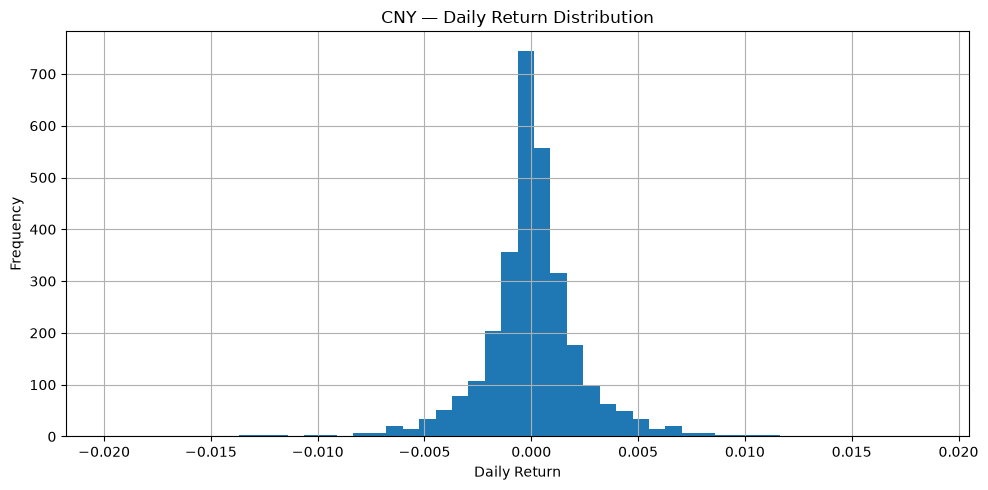

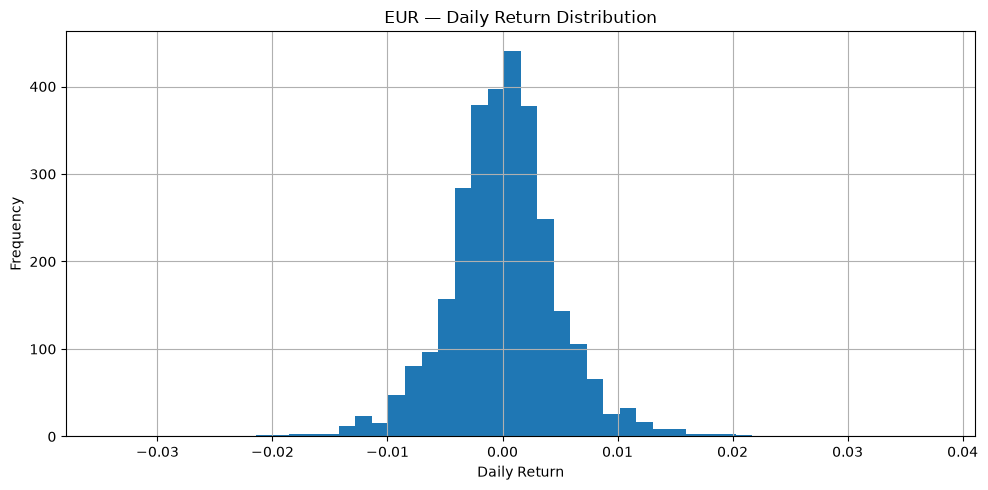

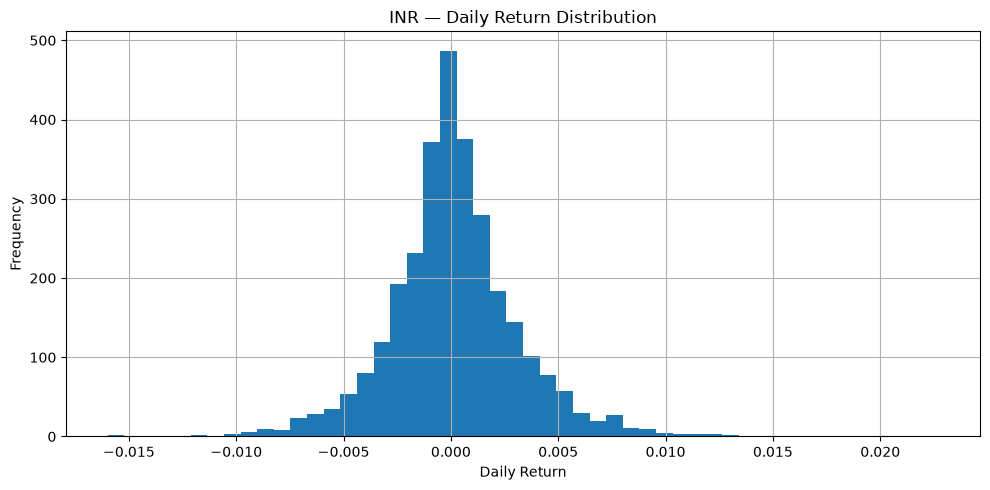

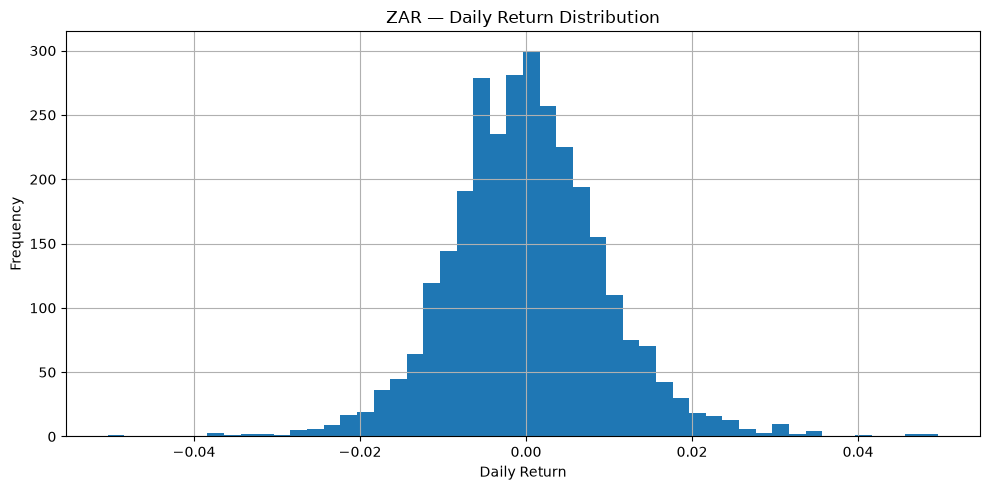

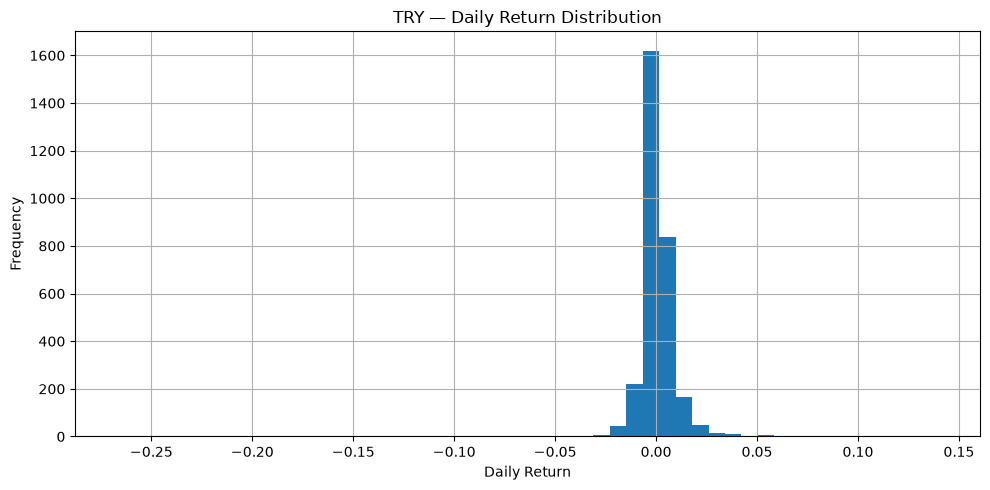

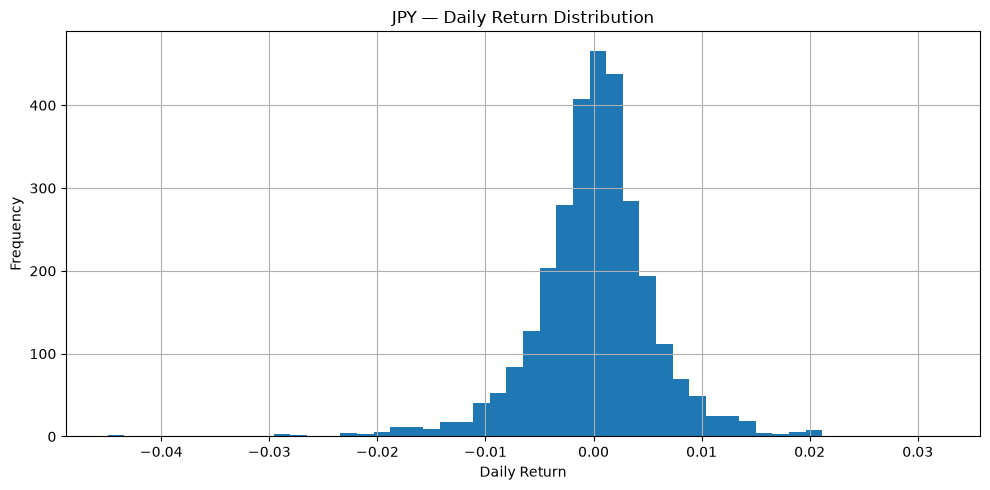

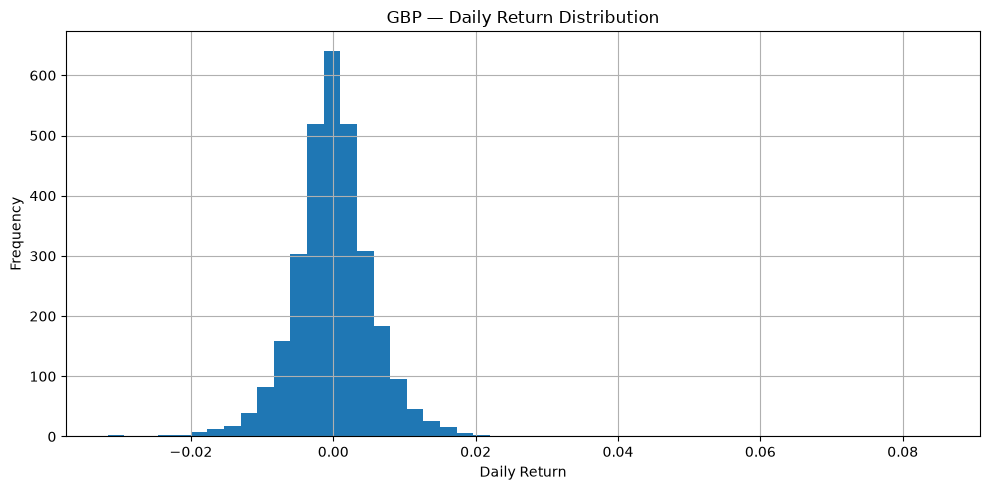

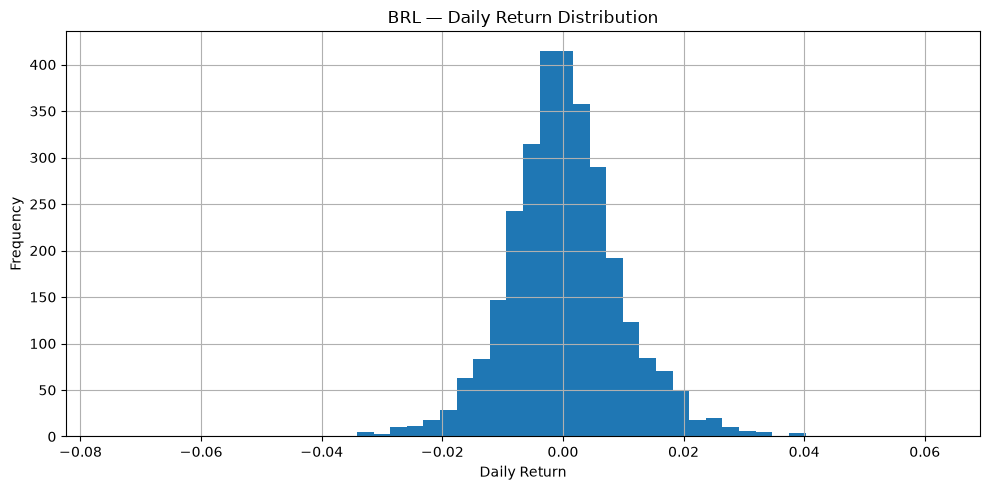

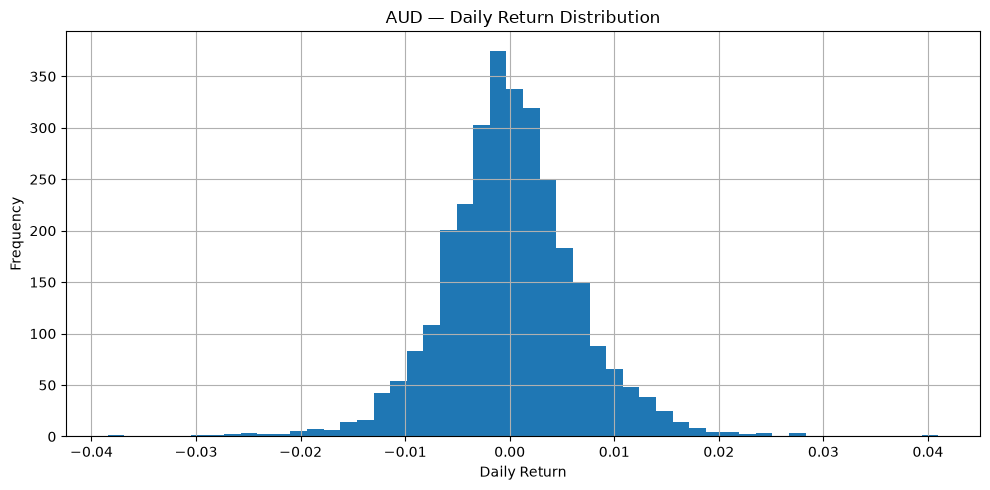

In [7]:
# ============================================================
# STEP 5.4 — Visualize Return Distributions
# ============================================================

import matplotlib.pyplot as plt

return_columns = [col for col in df_returns.columns if col.endswith("_return")]

for col in return_columns:
    
    currency = col.replace("_return", "")
    
    plt.figure(figsize=(10, 5))
    
    plt.hist(
        df_returns[col].dropna(),
        bins=50
    )
    
    plt.title(f"{currency} — Daily Return Distribution")
    plt.xlabel("Daily Return")
    plt.ylabel("Frequency")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

Step6: Rolling volatility

In [10]:
# ============================================================
# STEP 6.1 — 30-Day Rolling Volatility
# ============================================================

df_volatility = df_returns[["Day"]].copy()

return_columns = [col for col in df_returns.columns if col.endswith("_return")]

for col in return_columns:
    
    currency = col.replace("_return", "")
    
    df_volatility[currency + "_vol30"] = (
        df_returns[col].rolling(window=30).std()        # Calculate the standard deviation of the returns inside that 30-day window.
    )

print("Shape:", df_volatility.shape)

print("\nColumns:")
print(df_volatility.columns.tolist())

print("\nFirst 35 rows:")
print(df_volatility.head(35))

Shape: (2996, 10)

Columns:
['Day', 'CNY_vol30', 'EUR_vol30', 'INR_vol30', 'ZAR_vol30', 'TRY_vol30', 'JPY_vol30', 'GBP_vol30', 'BRL_vol30', 'AUD_vol30']

First 35 rows:
          Day  CNY_vol30  EUR_vol30  INR_vol30  ZAR_vol30  TRY_vol30  \
0  2015-01-02        NaN        NaN        NaN        NaN        NaN   
1  2015-01-05        NaN        NaN        NaN        NaN        NaN   
2  2015-01-06        NaN        NaN        NaN        NaN        NaN   
3  2015-01-07        NaN        NaN        NaN        NaN        NaN   
4  2015-01-08        NaN        NaN        NaN        NaN        NaN   
5  2015-01-09        NaN        NaN        NaN        NaN        NaN   
6  2015-01-12        NaN        NaN        NaN        NaN        NaN   
7  2015-01-13        NaN        NaN        NaN        NaN        NaN   
8  2015-01-14        NaN        NaN        NaN        NaN        NaN   
9  2015-01-15        NaN        NaN        NaN        NaN        NaN   
10 2015-01-16        NaN        NaN    